---------------------------------------------------------------------------------------------------------------
# Final Evaluation
---------------------------------------------------------------------------------------------------------------
## Content log:
1. Import Libraries and setting paths
2. Loading Model Configuration
3. Load and preprocess test data
4. Loading Model
5. Creating and Saving Confusion Matrix
6. Creating and Saving ROC Curve
7. Key Observations
---------------------------------------------------------------------------------------------------------------

# 01. Import Libraries and setting paths

In [5]:
import sys
import os
sys.path.append(os.path.abspath("../../"))
import pandas as pd
import pickle
import yaml
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from src.target_engineering import create_target
from src.utils_model import load_scaler, apply_scaler
os.makedirs("../../visuals_and_reports/modeling_analysis", exist_ok=True)

# 02. Loading Model Configuration

In [6]:
with open("../../configs/model.yaml", "r") as f:
    config = yaml.safe_load(f)

# 03. Load and preprocess test data

In [8]:
test = pd.read_csv("../../data/splits/test.csv")
test = create_target(test)
drop_cols = ["Date", "Ticker", "Returns", "Lag_1"]
X_test = test.drop("target", axis=1).drop(columns=drop_cols, errors="ignore")
y_test = test["target"]
scaler_path = os.path.abspath("../../" + config["scaler_path"])
scaler = load_scaler(scaler_path)
scale_cols = ['Close', 'Ma_7', 'Ma_30', 'Volatility']
X_test[scale_cols] = apply_scaler(scaler, X_test[scale_cols])

# 04. Loading Model

In [ ]:
with open("../../models/best_model.pkl", "rb") as f:
    model = pickle.load(f)
y_pred = model.predict(X_test)

# 05. Creating and Saving Confusion Matrix

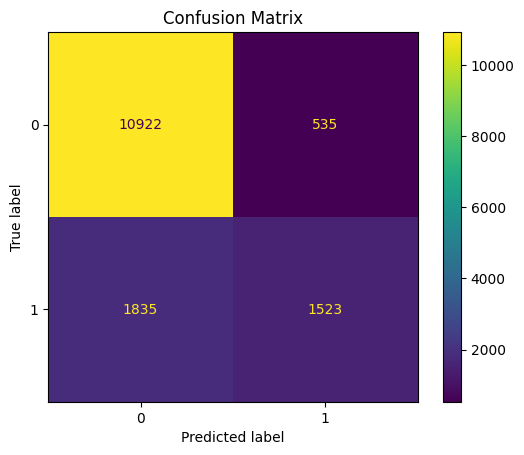

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.savefig("../../visuals_and_reports/modeling_analysis/confusion_matrix.png")
plt.show()

# 06. Creating and Saving ROC Curve

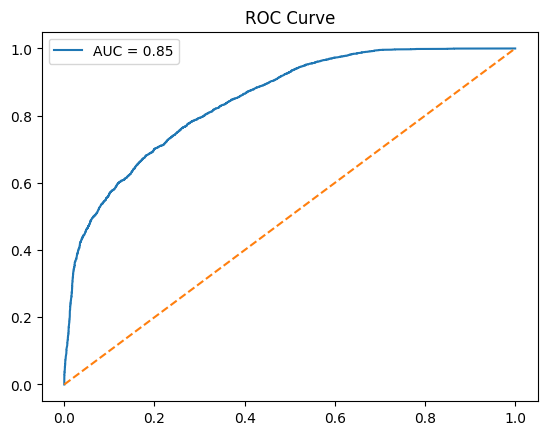

In [11]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.savefig("../../visuals_and_reports/modeling_analysis/roc_curve.png")
plt.show()

# 07. Key Observations
1. Overall AUC = 0.85, corresponding to 85%